# ¿Cómo funciona Alexa? Implementando una aplicación de Key Word Spotting.
## Este ejercicio está en su gran mayoría basado en el tutorial de google: Simple audio recognition: Recognizing keywords (Copyright 2020 The TensorFlow Authors.)
## Se agregan complementos de tratamiento y ejecución en tiempo real.

### Se dejan las indicaciones originales en inglés para familiarización de términos y complemento a las explicaciones dadas durante el taller.


<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://www.tensorflow.org/tutorials/audio/simple_audio">
    <img src="https://www.tensorflow.org/images/tf_logo_32px.png" />
    View on TensorFlow.org</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/audio/simple_audio.ipynb">
    <img src="https://www.tensorflow.org/images/colab_logo_32px.png" />
    Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tensorflow/docs/blob/master/site/en/tutorials/audio/simple_audio.ipynb">
    <img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />
    View source on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/docs/site/en/tutorials/audio/simple_audio.ipynb"><img src="https://www.tensorflow.org/images/download_logo_32px.png" />Download notebook</a>
  </td>
</table>

This tutorial demonstrates how to preprocess audio files in the WAV format and build and train a basic [automatic speech recognition](https://en.wikipedia.org/wiki/Speech_recognition) (ASR) model for recognizing ten different words. 

You will use a portion of the [Speech Commands dataset](https://www.tensorflow.org/datasets/catalog/speech_commands) ([Warden, 2018](https://arxiv.org/abs/1804.03209)), which contains short (one-second or less) audio clips of commands, such as "down", "go", "left", "no", "right", "stop", "up" and "yes".

Real-world speech and audio recognition [systems](https://ai.googleblog.com/search/label/Speech%20Recognition) are complex. But, like [image classification with the MNIST dataset](../quickstart/beginner.ipynb), this tutorial should give you a basic understanding of the techniques involved.

## Configuración

Import necessary modules and dependencies. You'll be using `tf.keras.utils.audio_dataset_from_directory` (introduced in TensorFlow 2.10), which helps generate audio classification datasets from directories of `.wav` files. You'll also need [seaborn](https://seaborn.pydata.org) for visualization in this tutorial.

In [2]:
import os
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from IPython import display

# Set the seed value for experiment reproducibility.
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

In [3]:
import sounddevice as sd
from scipy.io.wavfile import write
from queue import Queue
from threading import Thread

## Tema 4. Trabajando con el conjunto de datos de audio
## Importando el dataset "mini Speech Commands"

To save time with data loading, you will be working with a smaller version of the Speech Commands dataset. The [original dataset](https://www.tensorflow.org/datasets/catalog/speech_commands) consists of over 105,000 audio files in the [WAV (Waveform) audio file format](https://www.aelius.com/njh/wavemetatools/doc/riffmci.pdf) of people saying 35 different words. This data was collected by Google and released under a CC BY license.

Download and extract the `mini_speech_commands.zip` file containing the smaller Speech Commands datasets with `tf.keras.utils.get_file`:

In [50]:
DATASET_PATH = 'data/mini_speech_commands'

data_dir = pathlib.Path(DATASET_PATH)
if not data_dir.exists():
  tf.keras.utils.get_file(
      'mini_speech_commands.zip',
      origin="http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip",
      extract=True,
      cache_dir='.', cache_subdir='data')

The dataset's audio clips are stored in eight folders corresponding to each speech command: `no`, `yes`, `down`, `go`, `left`, `up`, `right`, and `stop`:

In [1]:
DATASET_PATH = 'data/mini_speech_commands'

data_dir = pathlib.Path(DATASET_PATH)
commands = np.array(tf.io.gfile.listdir(str(data_dir)))
commands = commands[(commands != 'README.md') & (commands != '.DS_Store')]
print('Commands:', commands)

NameError: name 'pathlib' is not defined

Divided into directories this way, you can easily load the data using `keras.utils.audio_dataset_from_directory`.

The audio clips are 1 second or less at 16kHz. The `output_sequence_length=16000` pads the short ones to exactly 1 second (and would trim longer ones) so that they can be easily batched.

In [52]:
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=data_dir,
    batch_size=64,
    validation_split=0.2,
    seed=0,
    output_sequence_length=16000,
    subset='both')

label_names = np.array(train_ds.class_names)
print()
print("label names:", label_names)

Found 8000 files belonging to 8 classes.
Using 6400 files for training.
Using 1600 files for validation.

label names: ['down' 'go' 'left' 'no' 'right' 'stop' 'up' 'yes']


The dataset now contains batches of audio clips and integer labels. The audio clips have a shape of `(batch, samples, channels)`.

In [53]:
#It indicates 2 vectors, one with data and the second with no data, because at loading asumes stereo,
#so, the second is useless because is mono audio
print(train_ds.element_spec)
print()

#If 64000 eleements in training divided into 64 batches, then there are 100 batches
print("Number of batches:", train_ds.cardinality())
print()

#Iterate through the dataset and convert the elements to NumPy arrays
for element in train_ds.take(1): # Take only one batch for demonstration
  print(element)
  print()
  numpy_element = element[0].numpy()  # Access the audio data and convert it to NumPy
  print("One batch shape:", numpy_element.shape) # Now you can print the shape
  print("Ex. Content of a batch:")
  print((numpy_element[0,:10]))



(TensorSpec(shape=(None, 16000, None), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))

Number of batches: tf.Tensor(100, shape=(), dtype=int64)

(<tf.Tensor: shape=(64, 16000, 1), dtype=float32, numpy=
array([[[ 2.9144287e-02],
        [ 3.0700684e-02],
        [ 3.2958984e-02],
        ...,
        [-1.3946533e-02],
        [-1.5716553e-02],
        [ 2.9113770e-02]],

       [[ 0.0000000e+00],
        [ 6.1035156e-05],
        [ 9.1552734e-05],
        ...,
        [ 0.0000000e+00],
        [ 9.1552734e-05],
        [ 6.1035156e-05]],

       [[-2.1362305e-04],
        [-3.6621094e-04],
        [-3.3569336e-04],
        ...,
        [-3.0517578e-04],
        [-3.9672852e-04],
        [-4.5776367e-04]],

       ...,

       [[ 3.3569336e-04],
        [ 9.7656250e-04],
        [ 1.6784668e-03],
        ...,
        [-1.5258789e-03],
        [-1.6784668e-03],
        [-9.7656250e-04]],

       [[-2.3803711e-03],
        [-2.2583008e-03],
        [-2.

This dataset only contains single channel audio, so use the `tf.squeeze` function to drop the extra axis:

In [30]:
def squeeze(audio, labels):
  audio = tf.squeeze(audio, axis=-1)
  return audio, labels

train_ds = train_ds.map(squeeze, tf.data.AUTOTUNE)
val_ds = val_ds.map(squeeze, tf.data.AUTOTUNE)

NameError: name 'train_ds' is not defined

The `utils.audio_dataset_from_directory` function only returns up to two splits. It's a good idea to keep a test set separate from your validation set.
Ideally you'd keep it in a separate directory, but in this case you can use `Dataset.shard` to split the validation set into two halves. Note that iterating over **any** shard will load **all** the data, and only keep its fraction.

In [55]:
test_ds = val_ds.shard(num_shards=2, index=0)
val_ds = val_ds.shard(num_shards=2, index=1)

In [56]:
for example_audio, example_labels in train_ds.take(1):
  print(example_audio.shape)
  print(example_labels.shape)

(64, 16000)
(64,)


Let's plot a few audio waveforms:

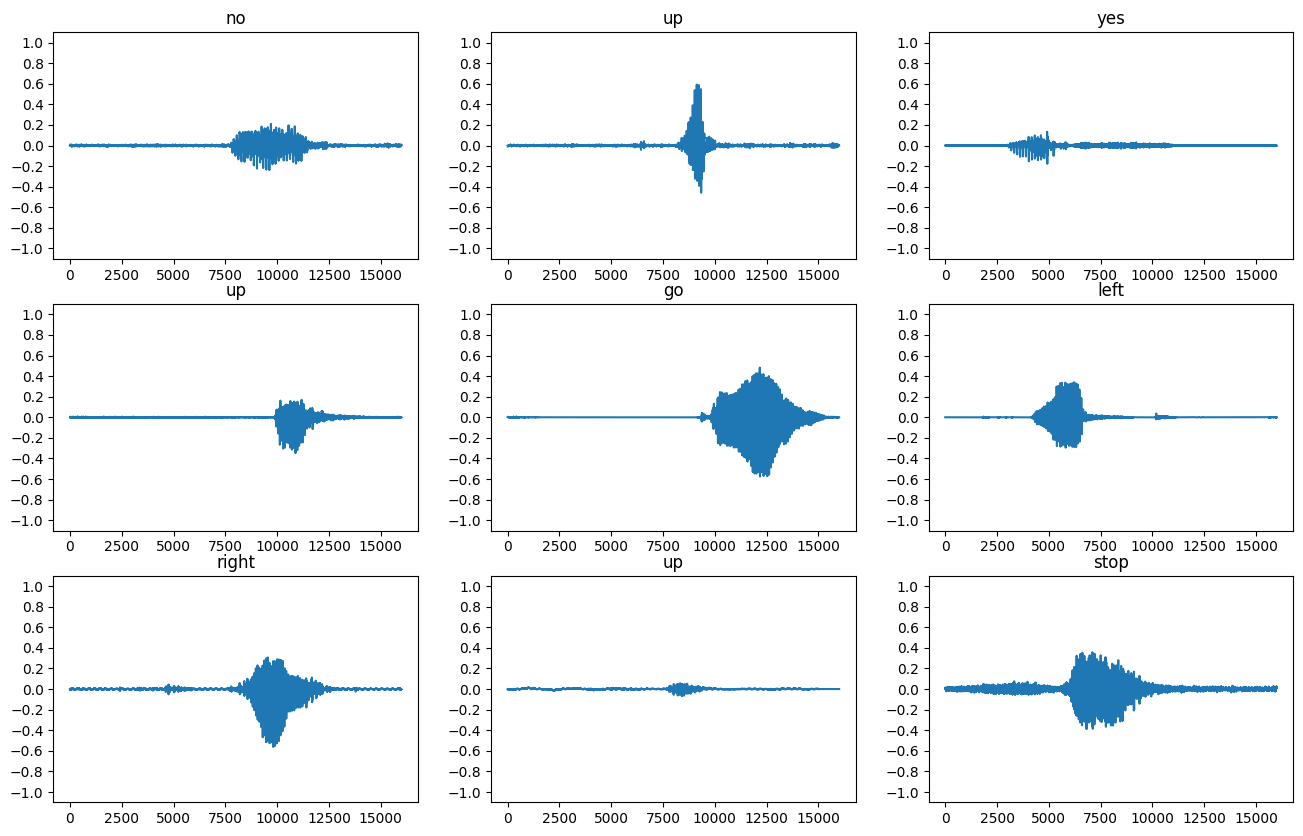

In [57]:
plt.figure(figsize=(16, 10))
rows = 3
cols = 3
n = rows * cols
for i in range(n):
  plt.subplot(rows, cols, i+1)
  audio_signal = example_audio[i]
  plt.plot(audio_signal)
  plt.title(label_names[example_labels[i]])
  plt.yticks(np.arange(-1.2, 1.2, 0.2))
  plt.ylim([-1.1, 1.1])

## Tema 5. Extracción de características de audio
## Convert waveforms to spectrograms

The waveforms in the dataset are represented in the time domain. Next, you'll transform the waveforms from the time-domain signals into the time-frequency-domain signals by computing the [short-time Fourier transform (STFT)](https://en.wikipedia.org/wiki/Short-time_Fourier_transform) to convert the waveforms to as [spectrograms](https://en.wikipedia.org/wiki/Spectrogram), which show frequency changes over time and can be represented as 2D images. You will feed the spectrogram images into your neural network to train the model.

A Fourier transform (`tf.signal.fft`) converts a signal to its component frequencies, but loses all time information. In comparison, STFT (`tf.signal.stft`) splits the signal into windows of time and runs a Fourier transform on each window, preserving some time information, and returning a 2D tensor that you can run standard convolutions on.

Create a utility function for converting waveforms to spectrograms:

- The waveforms need to be of the same length, so that when you convert them to spectrograms, the results have similar dimensions. This can be done by simply zero-padding the audio clips that are shorter than one second (using `tf.zeros`).
- When calling `tf.signal.stft`, choose the `frame_length` and `frame_step` parameters such that the generated spectrogram "image" is almost square. For more information on the STFT parameters choice, refer to [this Coursera video](https://www.coursera.org/lecture/audio-signal-processing/stft-2-tjEQe) on audio signal processing and STFT.
- The STFT produces an array of complex numbers representing magnitude and phase. However, in this tutorial you'll only use the magnitude, which you can derive by applying `tf.abs` on the output of `tf.signal.stft`.

In [31]:
def get_spectrogram(waveform):
  # Convert the waveform to a spectrogram via a STFT.
  spectrogram = tf.signal.stft(
      waveform, frame_length=255, frame_step=128)
  # Obtain the magnitude of the STFT.
  spectrogram = tf.abs(spectrogram)
  # Add a `channels` dimension, so that the spectrogram can be used
  # as image-like input data with convolution layers (which expect
  # shape (`batch_size`, `height`, `width`, `channels`).
  spectrogram = spectrogram[..., tf.newaxis]
  return spectrogram

Next, start exploring the data. Print the shapes of one example's tensorized waveform and the corresponding spectrogram, and play the original audio:

In [60]:
for i in range(3):
  label = label_names[example_labels[i]]
  waveform = example_audio[i]
  spectrogram = get_spectrogram(waveform)

  print('Label:', label)
  print('Waveform shape:', waveform.shape)
  print('Spectrogram shape:', spectrogram.shape)
  print('Audio playback')
  display.display(display.Audio(waveform, rate=16000))

Label: no
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


Label: up
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


Label: yes
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


Now, define a function for displaying a spectrogram:

In [32]:
def plot_spectrogram(spectrogram, ax):
  if len(spectrogram.shape) > 2:
    assert len(spectrogram.shape) == 3
    spectrogram = np.squeeze(spectrogram, axis=-1)
  # Convert the frequencies to log scale and transpose, so that the time is
  # represented on the x-axis (columns).
  # Add an epsilon to avoid taking a log of zero.
  log_spec = np.log(spectrogram.T + np.finfo(float).eps)
  height = log_spec.shape[0]
  width = log_spec.shape[1]
  X = np.linspace(0, np.size(spectrogram), num=width, dtype=int)
  Y = range(height)
  ax.pcolormesh(X, Y, log_spec)

Plot the example's waveform over time and the corresponding spectrogram (frequencies over time):

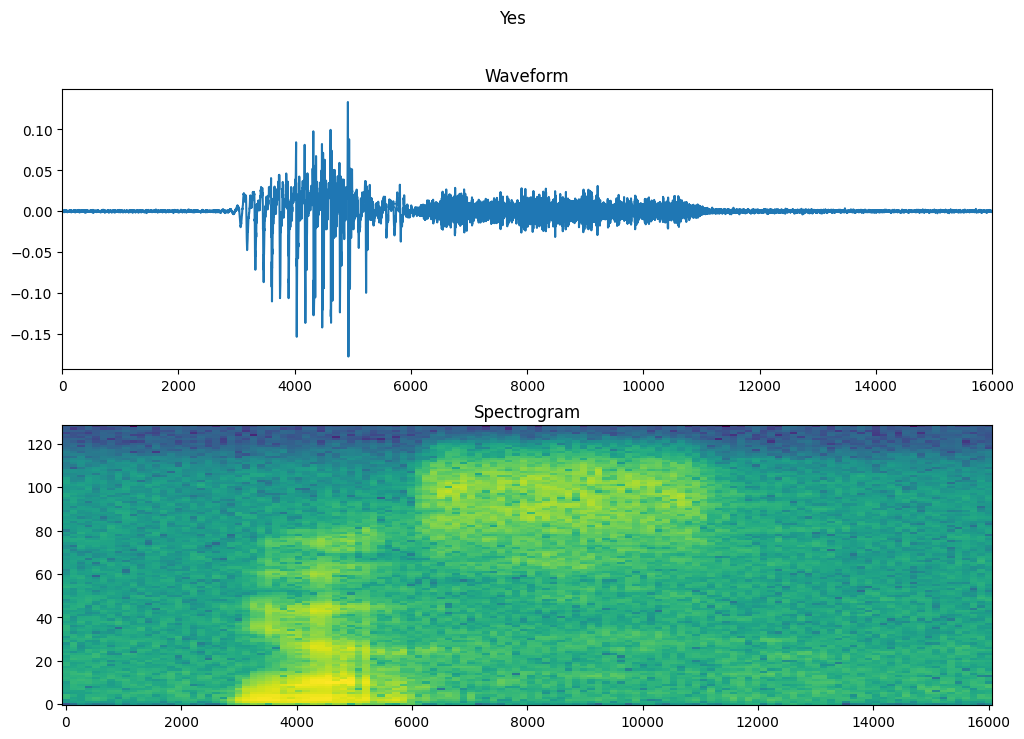

In [62]:
fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(waveform.shape[0])
axes[0].plot(timescale, waveform.numpy())
axes[0].set_title('Waveform')
axes[0].set_xlim([0, 16000])

plot_spectrogram(spectrogram.numpy(), axes[1])
axes[1].set_title('Spectrogram')
plt.suptitle(label.title())
plt.show()

Now, create spectrogram datasets from the audio datasets:

In [63]:
def make_spec_ds(ds):
  return ds.map(
      map_func=lambda audio,label: (get_spectrogram(audio), label),
      num_parallel_calls=tf.data.AUTOTUNE)

In [64]:
train_spectrogram_ds = make_spec_ds(train_ds)
val_spectrogram_ds = make_spec_ds(val_ds)
test_spectrogram_ds = make_spec_ds(test_ds)

Examine the spectrograms for different examples of the dataset:

In [65]:
for example_spectrograms, example_spect_labels in train_spectrogram_ds.take(1):
  break

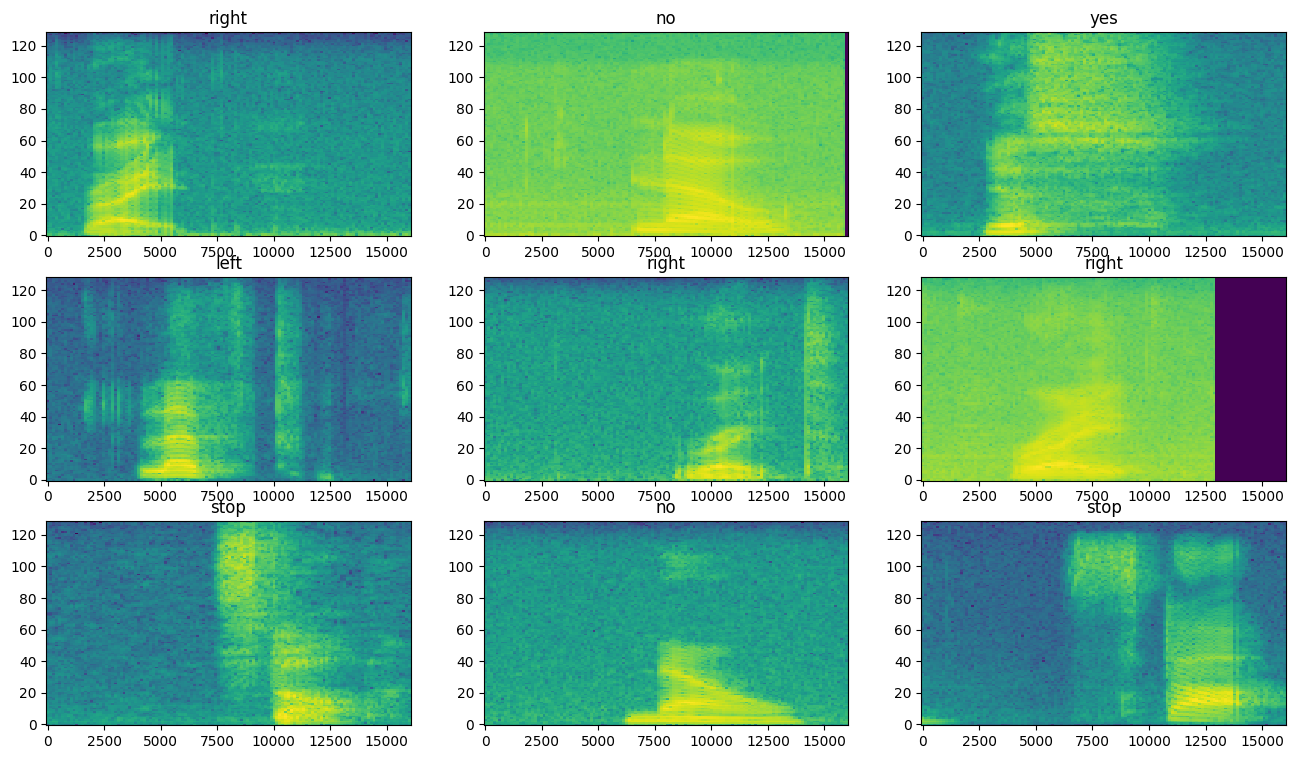

In [66]:
rows = 3
cols = 3
n = rows*cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 9))

for i in range(n):
    r = i // cols
    c = i % cols
    ax = axes[r][c]
    plot_spectrogram(example_spectrograms[i].numpy(), ax)
    ax.set_title(label_names[example_spect_labels[i].numpy()])

plt.show()

## Tema 6. Construcción de un modelo de aprendizaje profundo para clasificación de audio

## Build the model

Add `Dataset.cache` and `Dataset.prefetch` operations to reduce read latency while training the model:

In [67]:
train_spectrogram_ds = train_spectrogram_ds.cache().shuffle(10000).prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds = val_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)
test_spectrogram_ds = test_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)

For the model, you'll use a simple convolutional neural network (CNN), since you have transformed the audio files into spectrogram images.

Your `tf.keras.Sequential` model will use the following Keras preprocessing layers:

- `tf.keras.layers.Resizing`: to downsample the input to enable the model to train faster.
- `tf.keras.layers.Normalization`: to normalize each pixel in the image based on its mean and standard deviation.

For the `Normalization` layer, its `adapt` method would first need to be called on the training data in order to compute aggregate statistics (that is, the mean and the standard deviation).

In [68]:
input_shape = example_spectrograms.shape[1:]
print('Input shape:', input_shape)
num_labels = len(label_names)

# Instantiate the `tf.keras.layers.Normalization` layer.
norm_layer = layers.Normalization()
# Fit the state of the layer to the spectrograms
# with `Normalization.adapt`.
norm_layer.adapt(data=train_spectrogram_ds.map(map_func=lambda spec, label: spec))

model = models.Sequential([
    layers.Input(shape=input_shape),
    # Downsample the input.
    layers.Resizing(64, 64),
    # Normalize.
    norm_layer,
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(256, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(128, activation='relu'),
    #layers.Dropout(0.5),
    layers.Dense(num_labels),
])

model.summary()

Input shape: (124, 129, 1)
Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resizing_1 (Resizing)       (None, 64, 64, 1)         0         
                                                                 
 normalization_6 (Normalizat  (None, 64, 64, 1)        3         
 ion)                                                            
                                                                 
 conv2d_16 (Conv2D)          (None, 62, 62, 32)        320       
                                                                 
 max_pooling2d_11 (MaxPoolin  (None, 31, 31, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_17 (Conv2D)          (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_12 (MaxPooli

Configure the Keras model with the Adam optimizer and the cross-entropy loss:

In [69]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

##  Tema 7.- Entrenamiento del modelo
### Train the model over 10 epochs for demonstration purposes:

In [70]:
EPOCHS = 10
history = model.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=EPOCHS,
    callbacks=tf.keras.callbacks.EarlyStopping(verbose=1, patience=3),
)

Epoch 1/10
100/100 [==============================] - 34s 327ms/step - loss: 1.6912 - accuracy: 0.3828 - val_loss: 1.2915 - val_accuracy: 0.5221
Epoch 2/10
100/100 [==============================] - 29s 293ms/step - loss: 0.9104 - accuracy: 0.6753 - val_loss: 0.6360 - val_accuracy: 0.7826
Epoch 3/10
100/100 [==============================] - 28s 282ms/step - loss: 0.5782 - accuracy: 0.7959 - val_loss: 0.5746 - val_accuracy: 0.8086
Epoch 4/10
100/100 [==============================] - 28s 283ms/step - loss: 0.4300 - accuracy: 0.8572 - val_loss: 0.4340 - val_accuracy: 0.8620
Epoch 5/10
100/100 [==============================] - 28s 283ms/step - loss: 0.3226 - accuracy: 0.8886 - val_loss: 0.3859 - val_accuracy: 0.8789
Epoch 6/10
100/100 [==============================] - 28s 281ms/step - loss: 0.2669 - accuracy: 0.9064 - val_loss: 0.3880 - val_accuracy: 0.8841
Epoch 7/10
100/100 [==============================] - 28s 284ms/step - loss: 0.2127 - accuracy: 0.9259 - val_loss: 0.3737 - val_ac

Let's plot the training and validation loss curves to check how your model has improved during training:

Text(0, 0.5, 'Accuracy [%]')

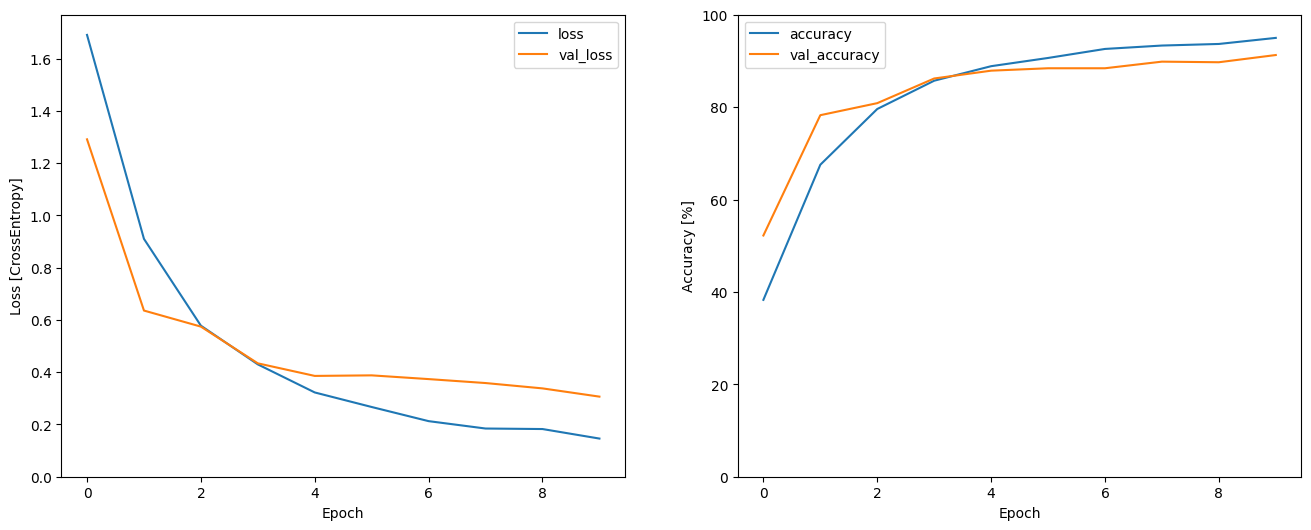

In [71]:
metrics = history.history
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.plot(history.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Epoch')
plt.ylabel('Loss [CrossEntropy]')

plt.subplot(1,2,2)
plt.plot(history.epoch, 100*np.array(metrics['accuracy']), 100*np.array(metrics['val_accuracy']))
plt.legend(['accuracy', 'val_accuracy'])
plt.ylim([0, 100])
plt.xlabel('Epoch')
plt.ylabel('Accuracy [%]')

## Tema 8. Despliegue y evaluación
## Evaluate the model performance

Run the model on the test set and check the model's performance:

In [72]:
model.evaluate(test_spectrogram_ds, return_dict=True)

13/13 [==============================] - 2s 129ms/step - loss: 0.3047 - accuracy: 0.9183


{'loss': 0.3046649694442749, 'accuracy': 0.9182692170143127}

### Display a confusion matrix

Use a [confusion matrix](https://developers.google.com/machine-learning/glossary#confusion-matrix) to check how well the model did classifying each of the commands in the test set:


In [75]:
y_pred = model.predict(test_spectrogram_ds)
print(y_pred.shape)
print(y_pred[0])

13/13 [==============================] - 1s 87ms/step
(832, 8)
[ -5.3426633  -1.6913043  -3.4803374 -10.177879   -5.9235263   8.32493
  24.241882  -11.526866 ]


In [80]:
#y_pred = tf.argmax(y_pred, axis=1)
print(y_pred[0])

tf.Tensor(6, shape=(), dtype=int64)


In [81]:
y_true = tf.concat(list(test_spectrogram_ds.map(lambda s,lab: lab)), axis=0)

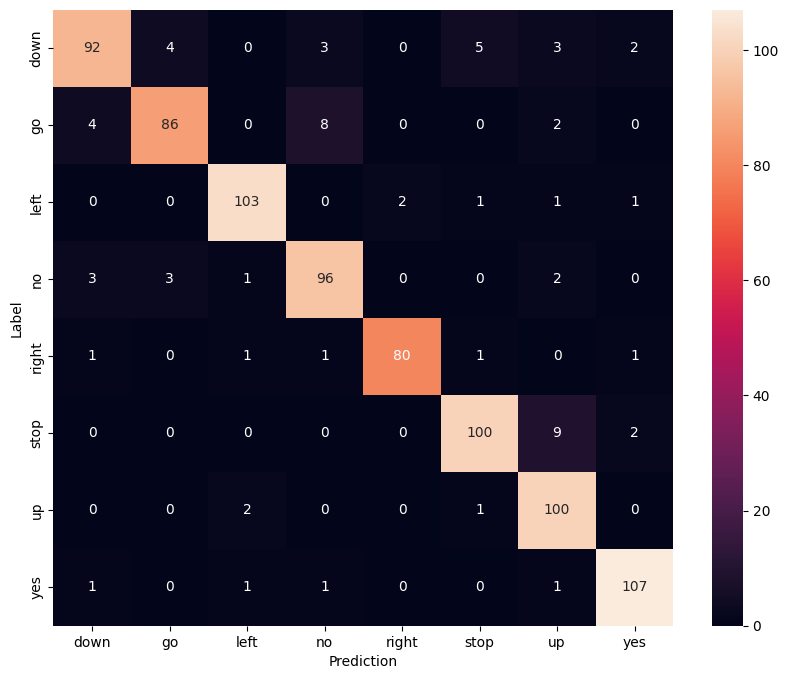

In [82]:
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=label_names,
            yticklabels=label_names,
            annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

## Run inference on an audio file

Finally, verify the model's prediction output using an input audio file of someone saying "no". How well does your model perform?

1:  ()
2:  (16000, 1)
3:  (16000,)
4:  (124, 129, 1)
5:  (1, 124, 129, 1)
tf.Tensor(
[[ 1.3868512   0.8134547  -1.3808659   8.38034    -4.7356544  -4.6340714
  -7.7982826  -0.58259964]], shape=(1, 8), dtype=float32)
Softmax preduction tf.Tensor(
[9.1634996e-02 5.1646195e-02 5.7551549e-03 9.9837746e+01 2.0095147e-04
 2.2243743e-04 9.3974058e-06 1.2786146e-02], shape=(8,), dtype=float32)


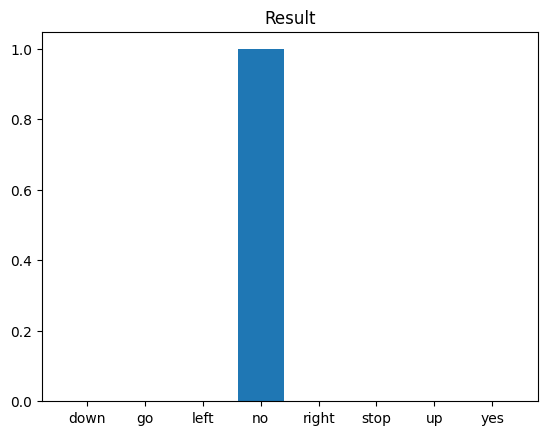

In [114]:
x = data_dir/'no/01bb6a2a_nohash_0.wav'
x = tf.io.read_file(str(x))
print("1: ", x.shape)
x, sample_rate = tf.audio.decode_wav(x, desired_channels=1, desired_samples=16000)
print("2: ", x.shape)
x = tf.squeeze(x, axis=-1)
print("3: ", x.shape)
waveform = x
x = get_spectrogram(x)
print("4: ", x.shape)
x = x[tf.newaxis,...]
print("5: ", x.shape)

prediction = model(x)
print(prediction)
x_labels = ['down', 'go', 'left', 'no', 'right', 'stop', 'up', 'yes'] # Same order as when the dataset was loaded
plt.bar(x_labels, tf.nn.softmax(prediction[0]))
print("Softmax preduction", tf.nn.softmax(prediction[0])*100)
plt.title('Result')
plt.show()

display.display(display.Audio(waveform, rate=16000))

As the output suggests, your model should have recognized the audio command as "no".

## Export the model with preprocessing

The model's not very easy to use if you have to apply those preprocessing steps before passing data to the model for inference. So build an end-to-end version:

In [202]:
class ExportModel(tf.Module):
  def __init__(self, model):
    self.model = model

    # Accept either a string-filename or a batch of waveforms.
    # You could add additional signatures for a single wave, or a ragged-batch.
    self.__call__.get_concrete_function(
        x=tf.TensorSpec(shape=(), dtype=tf.string)) #Path
    self.__call__.get_concrete_function(
       x=tf.TensorSpec(shape=[16000], dtype=tf.float32))  # Single waveform
    self.__call__.get_concrete_function(
       x=tf.TensorSpec(shape=[None, 16000], dtype=tf.float32)) #Batch of waveforms
      


  @tf.function
  def __call__(self, x):
    # If they pass a string, load the file and decode it.
    if x.dtype == tf.string:
      x = tf.io.read_file(x)
      x, _ = tf.audio.decode_wav(x, desired_channels=1, desired_samples=16000,)
      x = tf.squeeze(x, axis=-1) 
      #x = x[tf.newaxis, :]  

      
    x = get_spectrogram(x)  
    print(x.shape)

    if len(x.shape) == 3:
      x = x[tf.newaxis, ...]

    result = self.model(x, training=False)

    class_ids = tf.argmax(result, axis=-1)
    class_names = tf.gather(label_names, class_ids)
    return {'predictions':result,
            'class_ids': class_ids,
            'class_names': class_names}

Test run the "export" model:

In [203]:
export = ExportModel(model)
export(tf.constant(str(data_dir/'no/01bb6a2a_nohash_0.wav')))

(124, 129, 1)
(124, 129, 1)
(None, 124, 129, 1)


{'predictions': <tf.Tensor: shape=(1, 8), dtype=float32, numpy=
 array([[ 1.3868512 ,  0.8134547 , -1.3808659 ,  8.38034   , -4.7356544 ,
         -4.6340714 , -7.7982826 , -0.58259964]], dtype=float32)>,
 'class_ids': <tf.Tensor: shape=(1,), dtype=int64, numpy=array([3], dtype=int64)>,
 'class_names': <tf.Tensor: shape=(1,), dtype=string, numpy=array([b'no'], dtype=object)>}

Save the model

In [204]:
tf.saved_model.save(export, "saved")

(124, 129, 1)
(124, 129, 1)
(None, 124, 129, 1)


INFO:tensorflow:Assets written to: saved\assets


INFO:tensorflow:Assets written to: saved\assets


Reload the model, the reloaded model gives identical output:

In [3]:
imported = tf.saved_model.load("saved")

In [4]:
#Ejecutar 1 audio desde archivo
imported(str(data_dir/'no/01bb6a2a_nohash_0.wav'))

NameError: name 'data_dir' is not defined

In [6]:
#Ejecutar un vector de audio ya extraído
imported(waveform)

{'class_names': <tf.Tensor: shape=(1,), dtype=string, numpy=array([b'no'], dtype=object)>,
 'predictions': <tf.Tensor: shape=(1, 8), dtype=float32, numpy=
 array([[ 1.3868512 ,  0.8134547 , -1.3808659 ,  8.38034   , -4.7356544 ,
         -4.6340714 , -7.7982826 , -0.58259964]], dtype=float32)>,
 'class_ids': <tf.Tensor: shape=(1,), dtype=int64, numpy=array([3], dtype=int64)>}

# Inferencia de audios grabados al momento

In [5]:
# Recording parameters
sample_rate = 16000  # Must match your model's expected input
duration = 2  # Duration in seconds (adjust as needed)
#filename = "recorded_audio.wav" If you want to save it for later use

print("Recording...") #Speak almost inmediatelly after executing
audio = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1, dtype='float32')
sd.wait()  # Wait until recording is done
print("Recording processed")

# Save as WAV file (scipy expects int16, so we convert)
#scaled_audio = np.int16(audio * 32767)  # Normalize to 16-bit range
#write(filename, sample_rate, scaled_audio)

Recording...
Recording processed


(16000,)


NameError: name 'get_spectrogram' is not defined

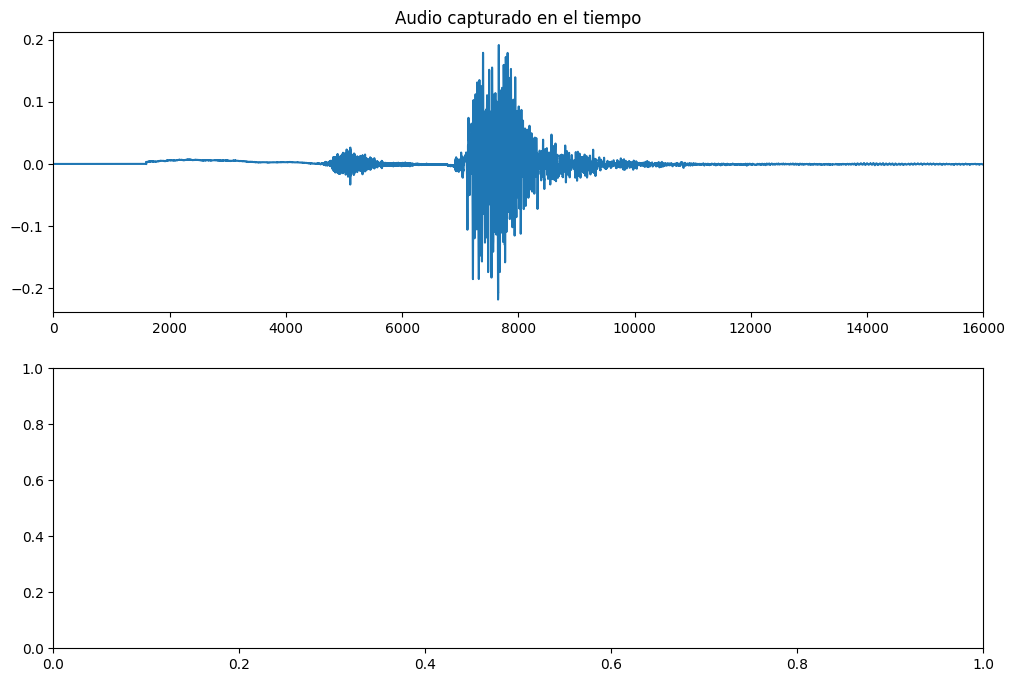

In [6]:
audio_chopped=audio[:16000,0]
print(audio_chopped.shape)

#Graficar
fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(audio_chopped.shape[0])
axes[0].plot(timescale, audio_chopped)
axes[0].set_title('Audio capturado en el tiempo')
axes[0].set_xlim([0, 16000])

spectrogram = get_spectrogram(audio_chopped)
plot_spectrogram(spectrogram, axes[1])
axes[1].set_title('Spectrograma')
plt.show()

Softmax preduction tf.Tensor(
[6.0120586e-04 1.9154038e-02 4.2223010e-06 3.3537399e-05 1.8117545e-06
 9.9906631e+01 7.3581286e-02 1.3785100e-06], shape=(8,), dtype=float32)


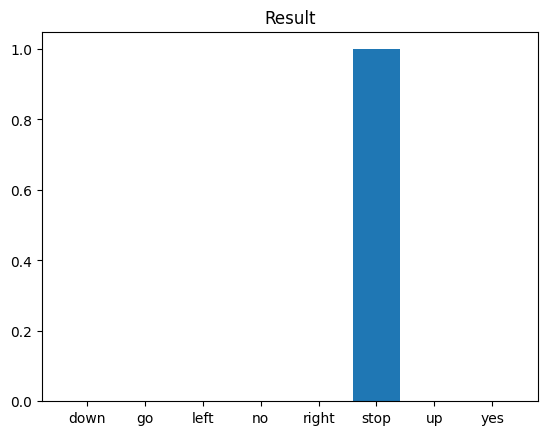

In [7]:
#Realizar predicción del audio grabado
prediction=imported(audio_chopped)
x_labels = ['down', 'go', 'left', 'no', 'right', 'stop', 'up', 'yes'] # Same order as when the dataset was loaded
plt.bar(x_labels, tf.nn.softmax(prediction['predictions'][0]))
print("Softmax preduction", tf.nn.softmax(prediction['predictions'][0])*100)
plt.title('Result')
plt.show()

display.display(display.Audio(audio_chopped, rate=sample_rate))

In [12]:
# Load your trained model
model = imported  # Replace with your model path

# Parameters
SAMPLE_RATE = 16000  # Must match your model's expected input
CHUNK_DURATION = 1.0  # Process 1-second chunks (adjust as needed)
CHUNK_SIZE = int(SAMPLE_RATE * CHUNK_DURATION)
THRESHOLD = 0.8  # Confidence threshold for detection (adjust as needed)
TARGET_CLASS = "up"  # Replace with your target word (e.g., "yes", "no")

# Queue for audio chunks
audio_queue = Queue()

def audio_callback(indata, frames, time, status):
    """Callback to capture audio chunks."""
    audio_queue.put(indata.copy())

def process_audio():
    """Process audio chunks and run predictions."""
    while True:
        # Get the latest audio chunk
        audio_chunk = audio_queue.get()
        
        # Remove extra dimensions and convert to float32
        audio_chunk = np.squeeze(audio_chunk).astype(np.float32)
        
        # Pad/trim to CHUNK_SIZE if needed
        if len(audio_chunk) < CHUNK_SIZE:
            padded = np.zeros(CHUNK_SIZE)
            padded[:len(audio_chunk)] = audio_chunk
            audio_chunk = padded
        else:
            audio_chunk = audio_chunk[:CHUNK_SIZE]
        
        # Predict
        prediction = model(audio_chunk)
        class_name = prediction["class_names"].numpy()[0].decode()
        confidence = tf.nn.softmax(prediction["predictions"])
        confidence = np.max(confidence)
        #confidence = tf.reduce_max(prediction["predictions"]).numpy()
        
        # Trigger action if target word is detected with high confidence
        #Para la detección de una sola palabra
        if class_name == TARGET_CLASS and confidence > THRESHOLD:
            print(f"✅ Detected '{TARGET_CLASS}' (Confidence: {confidence:.2f})")
            # Add your custom action here (e.g., play a sound, send a request)

        #Revisar cualquier palabra detectada. Útil para hacer las matrices de confusión y evaluar
        #if confidence > THRESHOLD:
        #    print(f"✅ Detected '{class_name}' (Confidence: {confidence:.2f})")
        #    # Add your custom action here (e.g., play a sound, send a request)    

# Start audio stream
stream = sd.InputStream(
    samplerate=SAMPLE_RATE,
    channels=1,
    callback=audio_callback,
    blocksize=CHUNK_SIZE
)

print("🎤 Listening... Press Ctrl+C to stop.")

# Start processing thread
processor_thread = Thread(target=process_audio, daemon=True)
processor_thread.start()

# Keep the stream alive
with stream:
    while True:
        sd.sleep(100)  # Run indefinitely

🎤 Listening... Press Ctrl+C to stop.
✅ Detected 'up' (Confidence: 0.82)
✅ Detected 'up' (Confidence: 0.95)
✅ Detected 'up' (Confidence: 0.94)
✅ Detected 'up' (Confidence: 0.97)
✅ Detected 'up' (Confidence: 0.99)
✅ Detected 'up' (Confidence: 1.00)


KeyboardInterrupt: 

### ¿Qué modificar para que los valores de predicción estén en procentajes?

## Next steps

This tutorial demonstrated how to carry out simple audio classification/automatic speech recognition using a convolutional neural network with TensorFlow and Python. To learn more, consider the following resources:

- The [Sound classification with YAMNet](https://www.tensorflow.org/hub/tutorials/yamnet) tutorial shows how to use transfer learning for audio classification.
- The notebooks from [Kaggle's TensorFlow speech recognition challenge](https://www.kaggle.com/c/tensorflow-speech-recognition-challenge/overview).
- The
[TensorFlow.js - Audio recognition using transfer learning codelab](https://codelabs.developers.google.com/codelabs/tensorflowjs-audio-codelab/index.html#0) teaches how to build your own interactive web app for audio classification.
- [A tutorial on deep learning for music information retrieval](https://arxiv.org/abs/1709.04396) (Choi et al., 2017) on arXiv.
- TensorFlow also has additional support for [audio data preparation and augmentation](https://www.tensorflow.org/io/tutorials/audio) to help with your own audio-based projects.
- Consider using the [librosa](https://librosa.org/) library for music and audio analysis.